## Problem Definition and Dataset Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from collections import Counter

In [2]:
df = pd.read_csv("Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [5]:
df.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

In [6]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [7]:
ans = df.isnull().sum()

In [8]:
ans

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [9]:
ans = df['Default'].unique()
ans

array([0, 1], dtype=int64)

In [10]:
cov = df['LoanAmount'].corr(df['CreditScore'])
cov

0.0012612695708441354

In [11]:
df.drop("LoanID", axis=1, inplace=True)

In [12]:
print(df.columns)

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default'],
      dtype='object')


In [13]:
ans = df.isnull().sum()
ans

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [14]:
df

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [15]:
X = df.drop("Default", axis=1)
y = df["Default"]


In [16]:
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(include=[np.number]).columns

In [17]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [18]:
X

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education_High School,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
0,56,85994,50587,520,80,4,15.23,36,0.44,False,...,False,False,False,True,True,False,False,False,True,True
1,69,50432,124440,458,15,1,4.81,60,0.68,False,...,False,True,False,False,False,False,False,False,True,True
2,46,84208,129188,451,26,3,21.17,24,0.31,False,...,True,False,False,True,True,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,True,...,False,True,False,False,False,True,False,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,False,...,True,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,19,37979,210682,541,109,4,14.11,12,0.85,False,...,False,True,False,False,False,False,False,False,True,False
255343,32,51953,189899,511,14,2,11.55,24,0.21,True,...,False,False,False,False,False,False,False,True,False,False
255344,56,84820,208294,597,70,3,5.29,60,0.50,True,...,False,True,False,True,True,False,False,False,False,True
255345,42,85109,60575,809,40,1,20.90,48,0.44,True,...,False,False,True,True,True,False,False,False,True,False


In [19]:
corr = df[num_cols].corr()
corr

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000


In [20]:
for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X[col] = np.clip(X[col], lower, upper)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


In [22]:
X

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education_High School,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
0,0.833990,0.089693,-1.086833,-0.341492,0.590533,1.341937,0.261771,-0.001526,-0.260753,False,...,False,False,False,True,True,False,False,False,True,True
1,1.701221,-0.823021,-0.044309,-0.731666,-1.285731,-1.343791,-1.308350,1.412793,0.778585,False,...,False,True,False,False,False,False,False,False,True,True
2,0.166888,0.043854,0.022715,-0.775718,-0.968209,0.446694,1.156831,-0.708685,-0.823728,False,...,True,False,False,True,True,False,False,False,False,False
3,-0.767053,-1.303452,-1.168538,1.061875,-1.718715,0.446694,-0.967805,-0.708685,-1.170174,True,...,False,True,False,False,False,True,False,False,False,False
4,1.100830,-1.592855,-1.671921,0.369631,-1.487790,1.341937,-1.052188,0.705634,0.995114,False,...,True,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,-1.634285,-1.142632,1.173101,-0.209337,1.427636,1.341937,0.093006,-1.415845,1.514783,False,...,False,True,False,False,False,False,False,False,True,False
255343,-0.767053,-0.783984,0.879724,-0.398130,-1.314597,-0.448549,-0.292744,-0.708685,-1.256785,True,...,False,False,False,False,False,False,False,True,False,False
255344,0.833990,0.059562,1.139391,0.143078,0.301877,0.446694,-1.236022,1.412793,-0.000918,True,...,False,True,False,True,True,False,False,False,False,True
255345,-0.099952,0.066979,-0.945840,1.477221,-0.564091,-1.343791,1.116146,0.705634,-0.260753,True,...,False,False,True,True,True,False,False,False,True,False


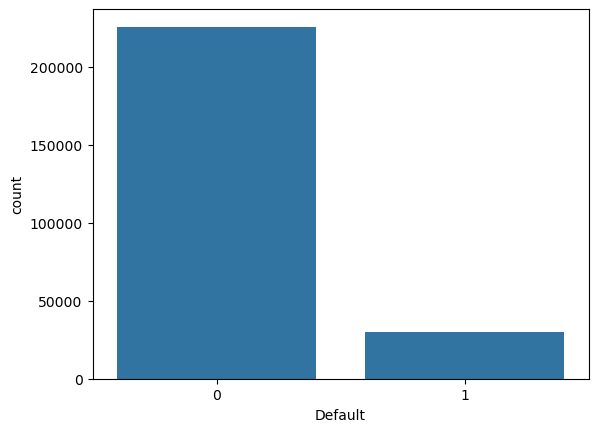

In [23]:
sns.countplot(x="Default", data=df)
plt.show()

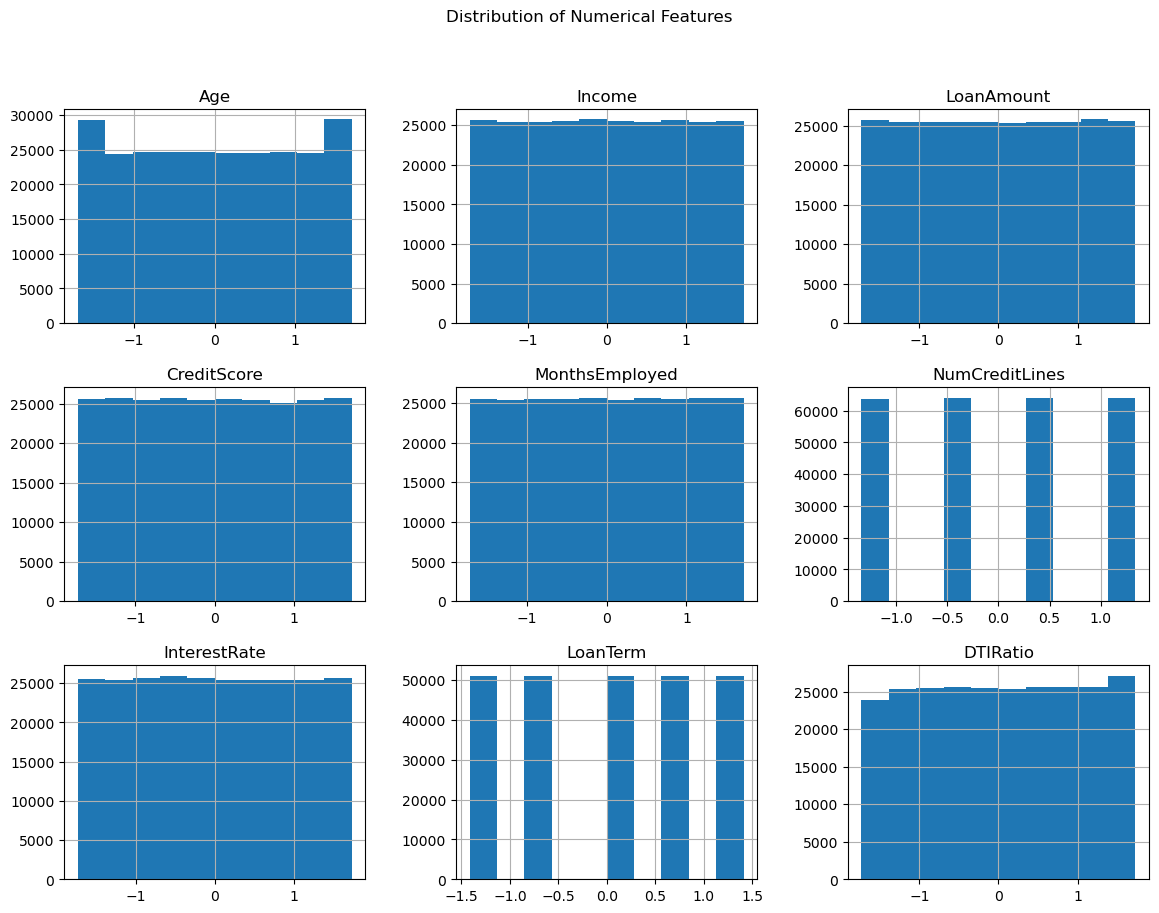

In [24]:
X[num_cols].hist(figsize=(14,10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

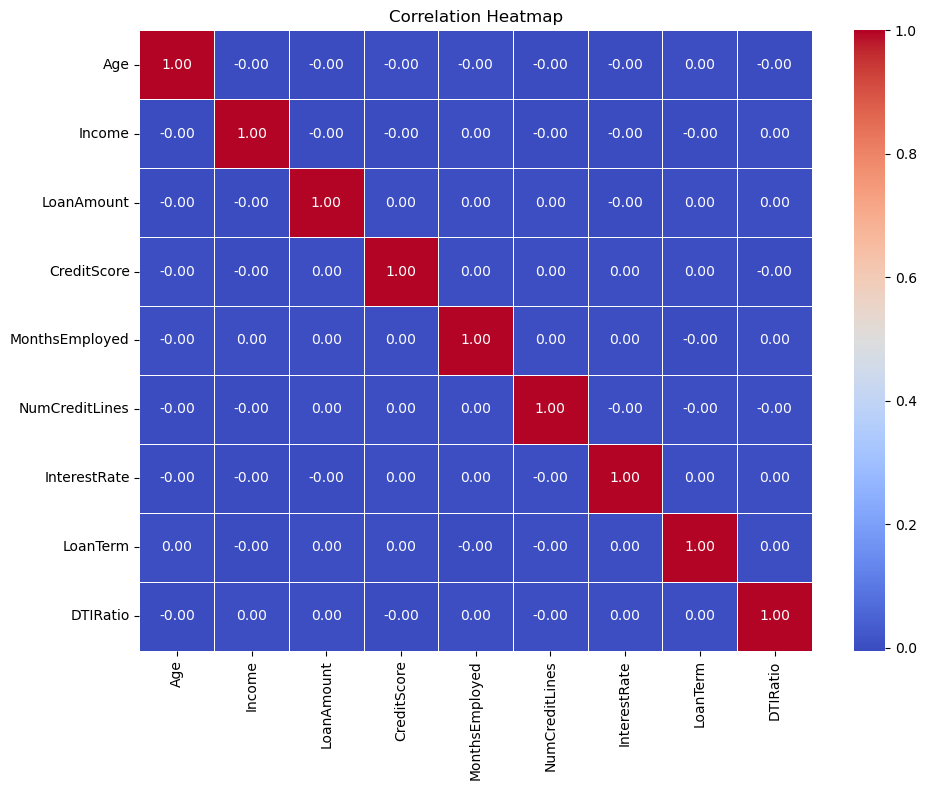

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [26]:
df

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


### Model Selection

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
X_train = X_train.to_numpy(dtype=np.float64)
X_test  = X_test.to_numpy(dtype=np.float64)

y_train = y_train.to_numpy(dtype=np.float64)
y_test  = y_test.to_numpy(dtype=np.float64)

In [29]:
# #SMOTE to handle class imbalance
# from imblearn.over_sampling import SMOTE

# print("Shape before SMOTE:", X_train.shape, y_train.shape)

# smote = SMOTE(random_state=42)
# X_train, y_train = smote.fit_resample(X_train, y_train)

# print("Shape after SMOTE:", X_train.shape, y_train.shape)


In [30]:
weights = np.zeros(X.shape[1])
bias = 0


In [31]:
def sigmoid(z):
    z = np.array(z, dtype=float)
    return 1 / (1 + np.exp(-z))


In [32]:
def train_logistic(X, y, lr=0.01, epochs=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0

    for _ in range(epochs):
        linear = np.dot(X, weights) + bias
        y_pred = sigmoid(linear)

        dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
        db = (1 / n_samples) * np.sum(y_pred - y)

        weights -= lr * dw
        bias -= lr * db

    return weights, bias


In [33]:
def predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    probs = sigmoid(linear)
    return (probs >= 0.5).astype(int)


In [34]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


In [35]:
weights, bias = train_logistic(X_train, y_train)

y_pred = predict(X_test, weights, bias)

acc = accuracy(y_test, y_pred)

print("Accuracy:", acc)



Accuracy: 0.88455061680047


# Task - 4

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[45166     4]
 [ 5892     8]]


In [37]:
from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred)
print(cr)


              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94     45170
         1.0       0.67      0.00      0.00      5900

    accuracy                           0.88     51070
   macro avg       0.78      0.50      0.47     51070
weighted avg       0.86      0.88      0.83     51070



In [38]:
y_train_pred = predict(X_train, weights, bias)
y_test_pred  = predict(X_test, weights, bias)

In [39]:
train_acc = accuracy(y_train, y_train_pred)
test_acc  = accuracy(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)
 

Training Accuracy: 0.8837901476916148
Testing Accuracy : 0.88455061680047


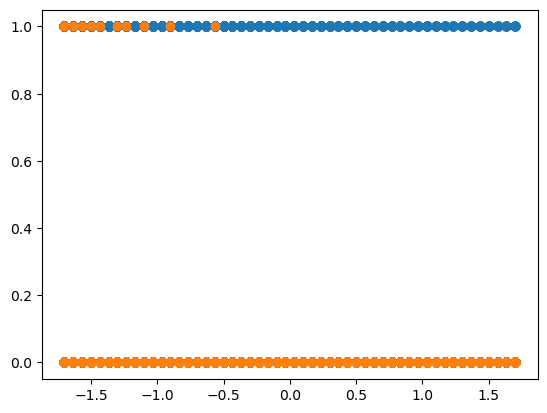

In [40]:
plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], y_test_pred)

### Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier


In [84]:
model_rf = RandomForestClassifier(random_state=42,class_weight='balanced')
model_rf = model_rf.fit(X_train,y_train)

### Random Forest Evaluation

In [85]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_rf = model_rf.predict(X_test)


print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8849813980810652

Random Forest Confusion Matrix:
 [[45132    38]
 [ 5836    64]]

Random Forest Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      1.00      0.94     45170
         1.0       0.63      0.01      0.02      5900

    accuracy                           0.88     51070
   macro avg       0.76      0.51      0.48     51070
weighted avg       0.86      0.88      0.83     51070



### Decision tree

In [86]:
from sklearn.tree import DecisionTreeClassifier

In [87]:
model_dtree = DecisionTreeClassifier(random_state=42)
model_dtree.fit(X_train, y_train)

y_pred_dtree = model_dtree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dtree))
print("\nDecision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dtree))
print("\nDecision Tree Classification Report:\n", classification_report(y_test, y_pred_dtree))

Decision Tree Accuracy: 0.8027804973565694

Decision Tree Confusion Matrix:
 [[39626  5544]
 [ 4528  1372]]

Decision Tree Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.88      0.89     45170
         1.0       0.20      0.23      0.21      5900

    accuracy                           0.80     51070
   macro avg       0.55      0.55      0.55     51070
weighted avg       0.82      0.80      0.81     51070



### Joblib

In [69]:
import joblib

In [78]:
joblib.dump(model_rf,"rf_model.pkl",compress=9)

['rf_model.pkl']

In [79]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [80]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [81]:
joblib.dump(num_cols, "numeric_columns.pkl")

['numeric_columns.pkl']